In [ ]:
!pip install sentence-transformers

In [ ]:
sentences = [
    # Cricket 
    "The bowler took a hat trick in the match",
    "The batsman scored a century under pressure",
    "The team won the cricket match by 5 wickets",
    "Spin bowling is very effective on dry pitches",

    # Cooking 
    "Cooking pasta requires boiling water and adding salt",
    "Baking a cake needs precise measurements",
    "Frying vegetables enhances their flavor",

    # Cybersecurity 
    "Strong passwords help protect user accounts",
    "Cybersecurity prevents unauthorized access to data",
    "Encryption keeps sensitive information safe"
]

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)
print(similarity_matrix)

[[ 1.0000002   0.39926568  0.5381329   0.33008903  0.00544822  0.12463307
   0.01475658 -0.01001242 -0.01385453  0.00792859]
 [ 0.39926568  1.          0.48412257  0.2982024   0.0038203   0.12380116
   0.06128081  0.01364907 -0.00297939  0.01711911]
 [ 0.5381329   0.48412257  1.          0.3213483  -0.01285618  0.06722492
   0.08143491 -0.02005725  0.03315043  0.02586656]
 [ 0.33008903  0.2982024   0.3213483   1.0000001   0.10180263  0.06829886
   0.18202673  0.15601517 -0.03095338  0.02831841]
 [ 0.00544822  0.0038203  -0.01285618  0.10180263  1.0000001   0.02509249
   0.15394908  0.03118848  0.01400759  0.05882348]
 [ 0.12463307  0.12380116  0.06722492  0.06829886  0.02509249  1.0000004
   0.03920016 -0.05715662 -0.00866027  0.08668105]
 [ 0.01475658  0.06128081  0.08143491  0.18202673  0.15394908  0.03920016
   0.9999999   0.09332243  0.04486295  0.06069162]
 [-0.01001242  0.01364907 -0.02005725  0.15601517  0.03118848 -0.05715662
   0.09332243  1.0000002   0.24700204  0.32407153]
 

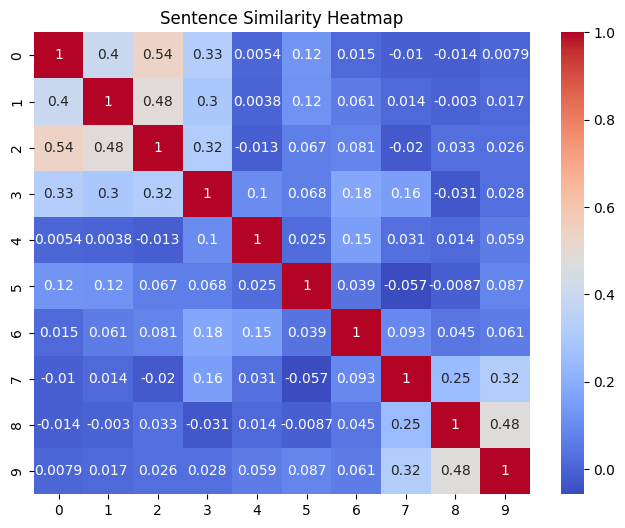

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm')
plt.title("Sentence Similarity Heatmap")
plt.show()

In [ ]:
new_sentence = "The bowler took three wickets in one over"
new_embedding = model.encode([new_sentence])

similarities = cosine_similarity(new_embedding, embeddings)[0]

top_2_idx = similarities.argsort()[-2:][::-1]

for i in top_2_idx:
    print(f"Sentence: {sentences[i]}")
    print(f"Similarity Score: {similarities[i]:.4f}")
    print()

Sentence: The team won the cricket match by 5 wickets
Similarity Score: 0.7185

Sentence: The bowler took a hat trick in the match
Similarity Score: 0.6425

